<a href="https://colab.research.google.com/github/AHMADAMJAD0/Deep-Learning-/blob/main/11__Vanishing_(or_Exploding)_Gradients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hy")

hy


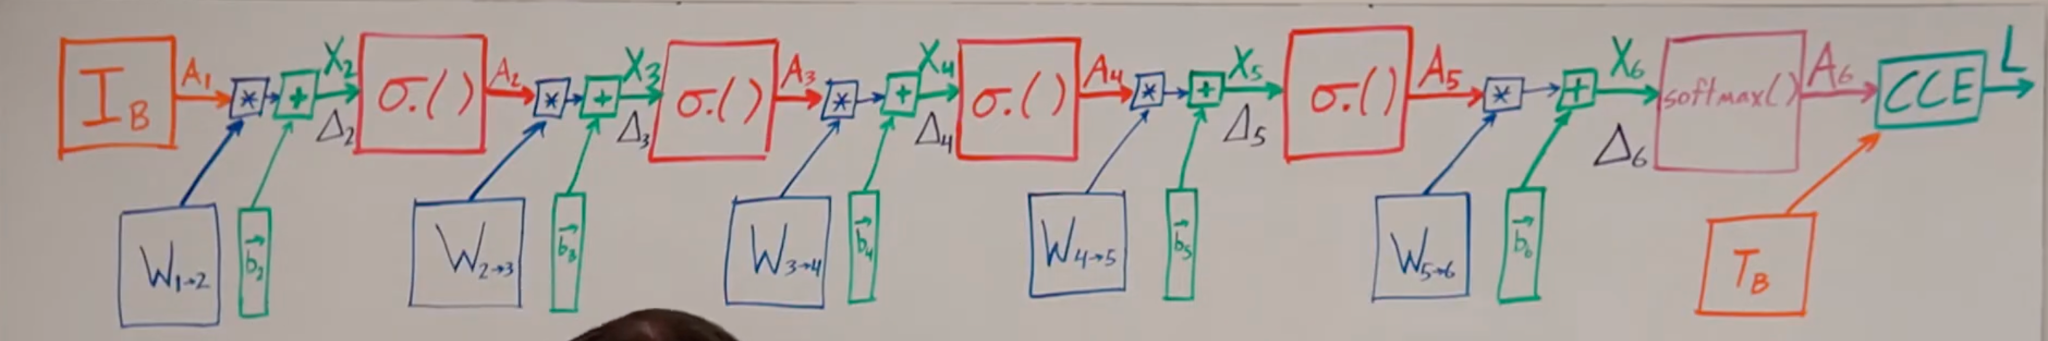

Sab se pehle ek line mein:

$$ \boxed{\text{Vanishing Gradient = gradient bohat chhota ho jana}} $$ $$ \boxed{\text{Exploding Gradient = gradient bohat bara ho jana}} $$

Aur dono problems mostly deep neural networks mein hoti hain.

Pehle gradient yaad karo

Backward pass mein hum loss se peeche jate hain:

Loss

 ↓

Output layer

 ↓


Hidden layer 3

 ↓


Hidden layer 2

 ↓

Hidden layer 1


Har layer par gradient calculate hota hai aur chain rule ki wajah se derivatives multiply hote rehte hain.

Conceptually:

$$ \frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial a_4} \times \frac{\partial a_4}{\partial a_3} \times \frac{\partial a_3}{\partial a_2} \times \frac{\partial a_2}{\partial a_1} \times \frac{\partial a_1}{\partial W_1} $$

Yani:

Peeche jate waqt bohat saare derivatives multiply hote hain.

Yahin se vanishing aur exploding gradient ki problem start hoti hai.

1. Vanishing Gradient

Suppose har layer ka derivative approximately:

$$ 0.5 $$

hai.

Agar 5 layers hon:

$$ 0.5\times0.5\times0.5\times0.5\times0.5 $$ $$ =0.03125 $$

Agar 20 layers hon:

$$ 0.5^{20} $$

value bohat hi chhoti ho jayegi.

Yani backward pass:

Gradient = 1

   ↓
   
   ×
   
   0.5

0.5

   ↓
   
   ×
   
   0.5

0.25

   ↓

0.125

   ↓

0.0625

   ↓

0.03125


Peeche ki layers tak gradient almost:

$$ 0 $$

ho gaya.

Isi ko kehte hain:

$$ \boxed{\text{Vanishing Gradient}} $$
Problem kya hogi?

Weight update:

$$ W_{new}=W_{old}-\eta \frac{\partial L}{\partial W} $$

Agar gradient:

$$ 0.000001 $$

hai, to weight almost change hi nahi karega.

Yani:

Early layers properly learn nahi karengi.

2. Exploding Gradient

Ab opposite case.

Suppose har derivative:

$$ 2 $$

hai.

5 layers:

$$ 2^5=32 $$

20 layers:

$$ 2^{20}=1,048,576 $$

Gradient peeche jate jate bohat bara ho gaya.


Gradient = 1

   ↓
   
   ×
   
   2

2
   
   ↓
   
    ×
    
    2
4

   ↓

8
   
   ↓

16

   ↓

32


Isay:

$$ \boxed{\text{Exploding Gradient}} $$

kehte hain.

Problem kya hogi?

Gradient bohat bara:

$$ \frac{\partial L}{\partial W}=100000 $$

to weight update bhi bohat bara ho sakta hai.

Result:

training unstable
loss jump karega
weights bohat large ho sakte hain
NaN values aa sakti hain
Ye activation functions se kaise connected hai?

Sigmoid ka derivative maximum around:

$$ 0.25 $$

hota hai.

Agar deep network mein repeatedly:

$$ 0.25\times0.25\times0.25... $$

multiply ho:

gradient bohat jaldi vanish karega.

Isi liye deep hidden layers mein sigmoid historically problematic thi.

Tanh bhi vanishing gradient suffer kar sakti hai.

ReLU positive region mein derivative:

$$ 1 $$

rakhti hai.

Isliye:

$$ \boxed{\text{ReLU vanishing gradient ko reduce karti hai}} $$

lekin completely solve nahi karti.

Deep Learning example

Suppose network:

Input
 ↓
Hidden 1
 ↓
Hidden 2
 ↓
Hidden 3
 ↓
Hidden 4
 ↓
Hidden 5
 ↓
Output

Forward pass mein information:

$$ Input\rightarrow Output $$

Backward pass:

$$ Output\rightarrow Input $$

Agar gradient har step par chhota hota gaya:

Output layer gradient = 0.8
Hidden 5 = 0.4
Hidden 4 = 0.2
Hidden 3 = 0.1
Hidden 2 = 0.05
Hidden 1 = 0.001



Why exactly hota hai?

Main reason:

$$ \boxed{\text{Chain Rule mein repeated multiplication}} $$

Agar multiplied numbers mostly:

$$ <1 $$

to:

$$ \boxed{\text{gradient vanish}} $$

Agar multiplied numbers mostly:

$$ >1 $$

to:

$$ \boxed{\text{gradient explode}} $$
Common solutions

Vanishing gradient ke liye commonly:

ReLU / Leaky ReLU / GELU
proper weight initialization
Xavier initialization
He initialization
Batch Normalization
Residual connections / Skip connections
LSTM / GRU for sequence models

Exploding gradient ke liye:

Gradient clipping
proper initialization
smaller learning rate
normalization
residual connections
Sab se important mental picture

BACKPROPAGATION

      ↓

Derivatives repeatedly multiply

      ↓

Values mostly < 1

      ↓

Gradient → 0

      ↓

VANISHING


Values mostly > 1

      ↓

Gradient → huge

      ↓

EXPLODING

Aur ek line mein:

Vanishing gradient mein early layers ko learning signal nahi milta; exploding gradient mein learning signal itna bara ho jata hai ke training unstable ho jati hai.


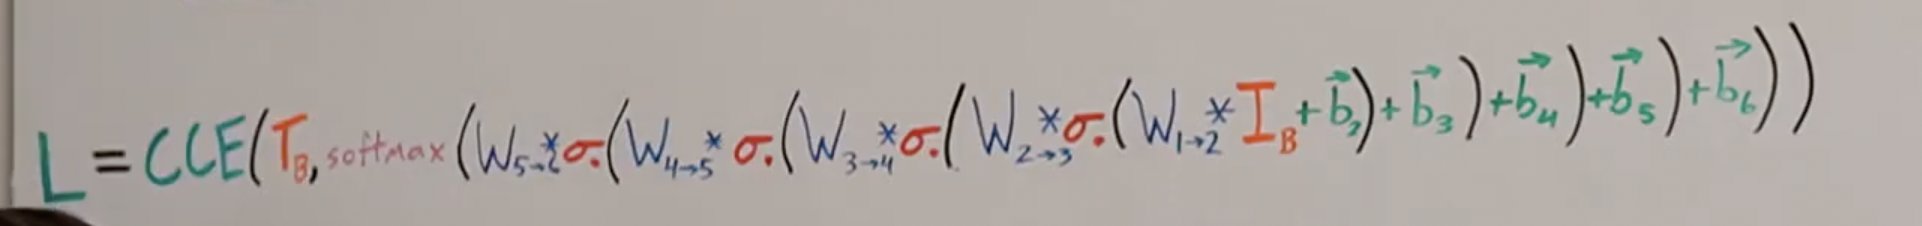

1. Pehli picture — Forward Pass

Board par roughly ye nested computation hai:

$$ Input \rightarrow W_{1\to2} \rightarrow \sigma \rightarrow W_{2\to3} \rightarrow \sigma \rightarrow W_{3\to4} \rightarrow \sigma \rightarrow W_{4\to5} \rightarrow \sigma \rightarrow W_{5\to6} \rightarrow Softmax \rightarrow CCE $$

Simple flow:


Input batch I_B
      ↓
W₁→₂ × Input + b₂
      ↓
Activation σ
      ↓
Layer 2 output
      ↓
W₂→₃ + b₃
      ↓
Activation σ
      ↓
Layer 3 output
      ↓
...
      ↓
Layer 6 raw scores
      ↓
Softmax
      ↓
Probabilities A₆
      ↓
Actual labels T_B
      ↓
Categorical Cross-Entropy
      ↓
Loss L

Yani pehli image sirf ye keh rahi hai:

Deep network mein ek layer ka output next layer ka input banta jata hai, aur end mein prediction ko actual label se compare karke loss nikalta hai.

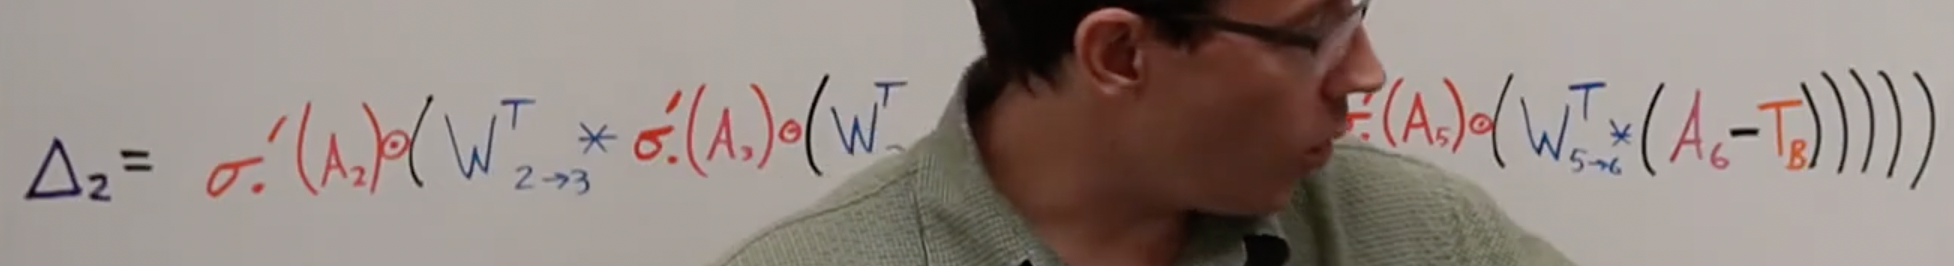

Ab doosri picture — Backward Pass

Ab loss mil gaya.

Ab hum poochte hain:

Layer 2 ke neurons/weights ne final loss mein kitna contribution diya?

Isliye loss se ulta travel karna padega:

Loss
 ↓
Layer 6
 ↓
Layer 5
 ↓
Layer 4
 ↓
Layer 3
 ↓
Layer 2

Board par \(\Delta_2\) isi cheez ko represent kar raha hai:

Δ
2 = Layer 2 ka backward error/gradient signal

3. Sabse pehle output layer ka error

Softmax + Categorical Cross-Entropy ke liye:

$$ \boxed{\Delta_6=A_6-T_B} $$

Yahan:

\(A_6\) = prediction
\(T_B\) = actual labels

Example:

Prediction:

$$ A_6= [0.7,0.2,0.1] $$

Actual:

$$ T_B= [1,0,0] $$

To:

$$ \Delta_6= [-0.3,0.2,0.1] $$

Ab network ko pata hai final output mein kitni correction required hai.

4. Layer 6 ka error Layer 5 tak kaise jata hai?

Board mein:

$$ W_{5\to6}^{T}(A_6-T_B) $$

hai.

Simple meaning:

Output error ko connection weights ke through Layer 5 mein peeche distribute karo.

So:


Output error Δ₆

      ↓

W₅→₆ᵀ

      ↓
      
Layer 5 tak error

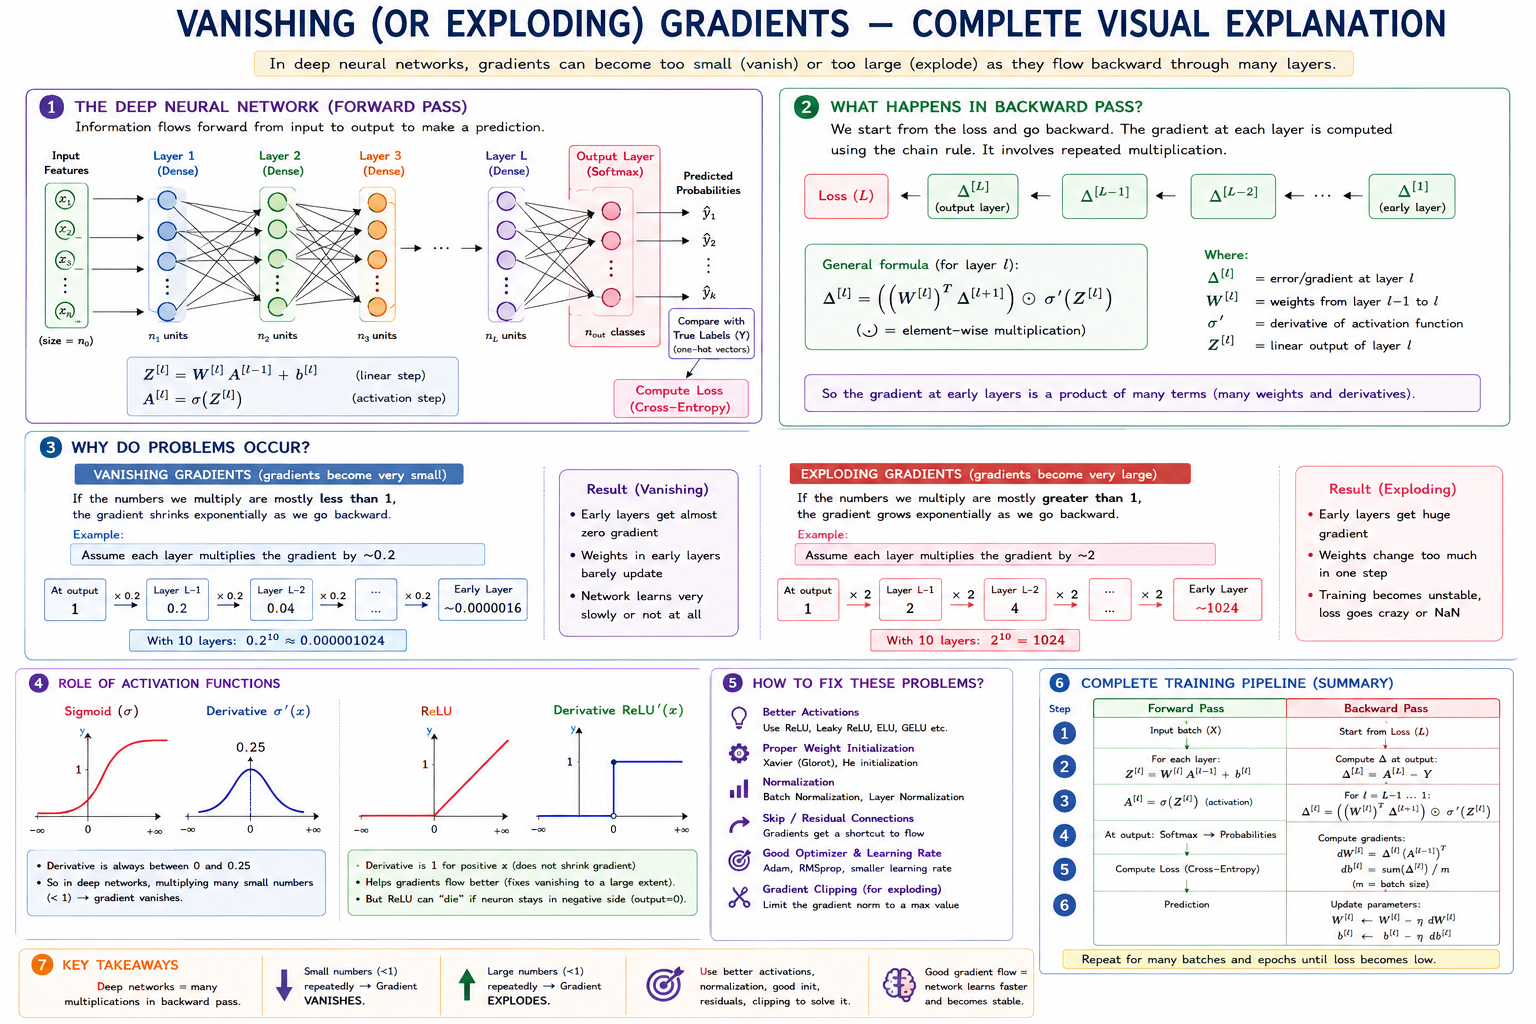